# Import Essential Libraries

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df = pd.read_csv("dataset/train-test.csv")
df.drop(columns=['load_id'], inplace=True)  # here you have to remove load_id cause it's not useful for our model
df.head()

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [64]:
# Understanding the data

shape = df.shape
columns = df.columns
info = df.info()
distribution = df.describe()
missing_values = df.isnull().sum()
duplicate_values = df.duplicated().sum()

print("-*" * 50)
print(f"Distribution of numeric columns: \n {distribution}")
print("-*" * 50)
print(f"The shape of the dataset is: {shape}")
print(f"Total columns: {columns}")
print("-*" * 50)
print(f"Missing values: \n {missing_values}")
print("-*" * 50)
print(f"Duplicates values:  {duplicate_values}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pickup        48000 non-null  object 
 1   delivery      48000 non-null  object 
 2   pickup_lat    48000 non-null  float64
 3   pickup_lon    48000 non-null  float64
 4   delivery_lat  48000 non-null  float64
 5   delivery_lon  48000 non-null  float64
 6   distance      48000 non-null  float64
 7   equipment     48000 non-null  object 
 8   weight        47700 non-null  float64
 9   date          48000 non-null  object 
 10  market_index  47626 non-null  float64
 11  quote_signal  48000 non-null  float64
 12  posted_rate   48000 non-null  float64
dtypes: float64(9), object(4)
memory usage: 4.8+ MB
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Distribution of numeric columns: 
          pickup_lat    pickup_lon  delivery_lat  delivery_

In [65]:
# Filling the missing values
df["weight"] = df["weight"].fillna(
    df["weight"].median()
)

df["market_index"] = df["market_index"].fillna(
    df["market_index"].median()
)

# EDA

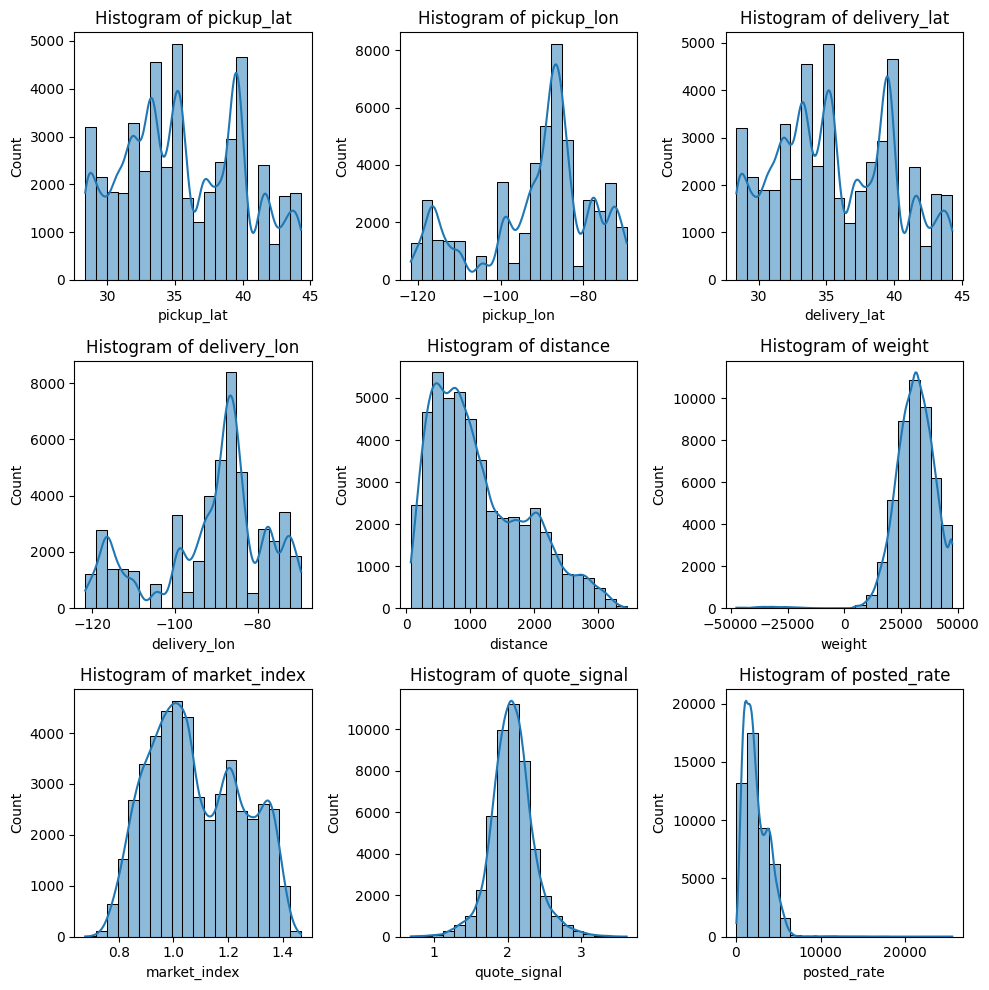

In [66]:
# Distribution of numeric columns
numeric_cols = [
    'pickup_lat', 'pickup_lon',
    'delivery_lat', 'delivery_lon',
    'distance', 'weight',
    'market_index',
    'quote_signal', 'posted_rate'
]

plt.figure(figsize=(10,10))
for idx, col in enumerate(numeric_cols):
    plt.subplot(3,3, idx+1)
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f"Histogram of {col}")
    
plt.tight_layout()
plt.show()

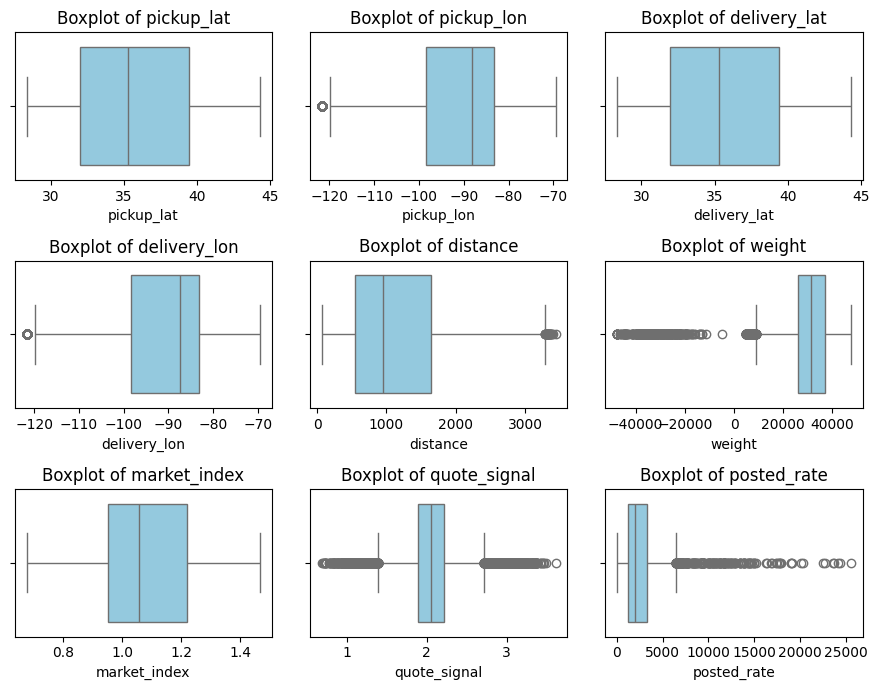

In [67]:
numeric_cols = [
    'pickup_lat', 'pickup_lon',
    'delivery_lat', 'delivery_lon',
    'distance', 'weight',
    'market_index',
    'quote_signal', 'posted_rate'
]

plt.figure(figsize=(9,7))
for idx, col in enumerate(numeric_cols):
    plt.subplot(3,3, idx+1)
    sns.boxplot(x = df[col], color='skyblue')
    plt.title(f"Boxplot of {col}")
    
plt.tight_layout()
plt.show()

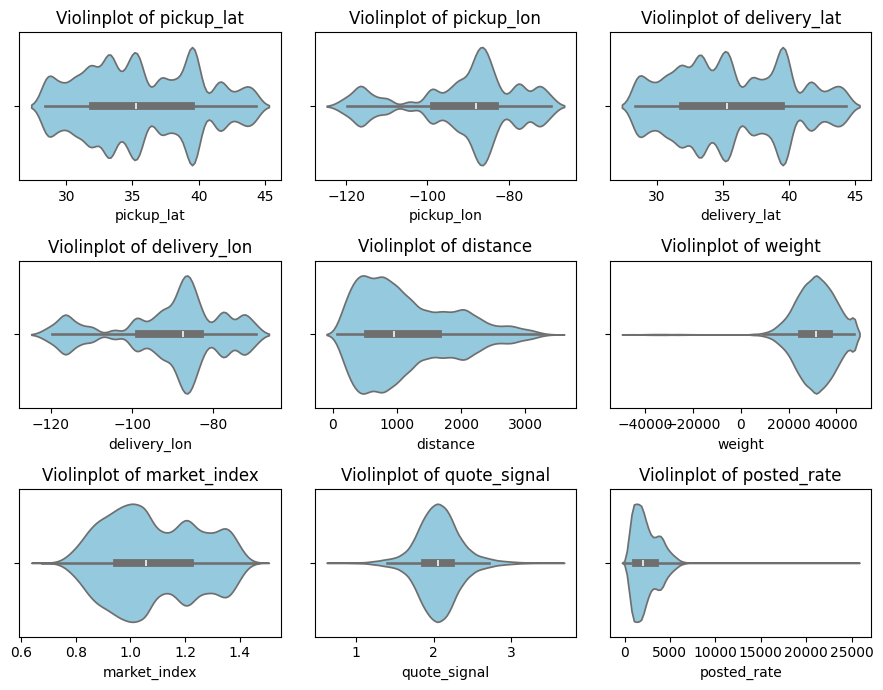

In [68]:
numeric_cols = [
    'pickup_lat', 'pickup_lon',
    'delivery_lat', 'delivery_lon',
    'distance', 'weight',
    'market_index',
    'quote_signal', 'posted_rate'
]

plt.figure(figsize=(9,7))
for idx, col in enumerate(numeric_cols):
    plt.subplot(3,3, idx+1)
    sns.violinplot(x = df[col], color='skyblue')
    plt.title(f"Violinplot of {col}")
    
plt.tight_layout()
plt.show()

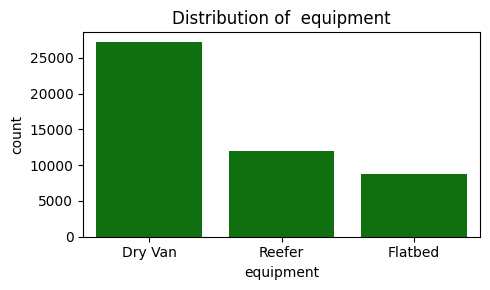

In [69]:
cat_cols = [
    'equipment'
]

plt.figure(figsize=(5,3))
for idx, col in enumerate(cat_cols):
    plt.subplot(1,1, idx+1)
    sns.countplot(x = df[col], color='g')
    plt.title(f"Distribution of  {col}")
    
plt.tight_layout()
plt.show()

In [70]:
print(f"Unique values for pickup:\n{df['pickup'].value_counts()}")

print('-*' * 50)

print(f"Unique values for delivery:\n{df['delivery'].value_counts()}")

Unique values for pickup:
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
                 ... 
Detroit           337
Washington        337
St. Louis         318
Las Vegas         277
Dallas            276
Name: count, Length: 64, dtype: int64
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Unique values for delivery:
delivery
Lexington      1197
Fort Wayne     1176
Baton Rouge    1167
Bakersfield    1156
Hartford       1143
               ... 
St. Louis       344
Birmingham      318
Detroit         307
Dallas          306
Las Vegas       292
Name: count, Length: 64, dtype: int64


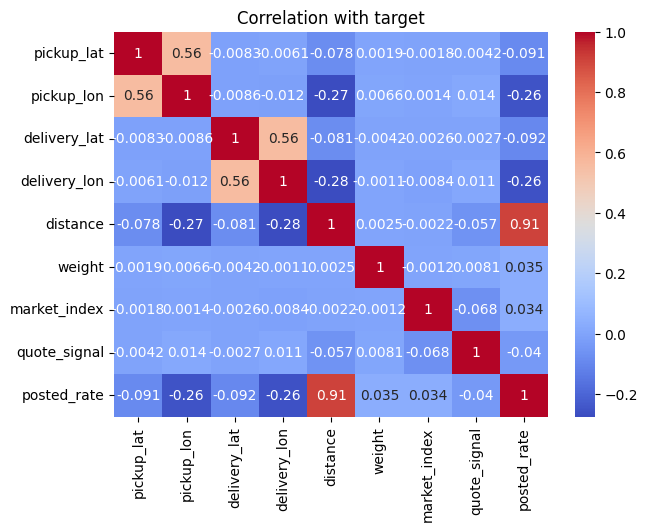

In [71]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(7,5))
sns.heatmap(data=corr, annot=True, cmap='coolwarm')
plt.title("Correlation with target")
plt.show()

### Exploratory Data Analysis

1. Checked **numerical and categorical features**, missing values, distributions, outliers, and correlations.
2. Found missing values in **weight** and **market_index** and filled them using **median imputation**.
3. Found some **negative values in weight**, which are not physically valid and should be treated as data-quality issues.
4. The **posted_rate** target has some high-value outliers. I will investigate them before deciding whether to remove them.
5. **Distance** has the strongest relationship with **posted_rate**, with a correlation of around **0.91**.
6. Overall, the dataset looks **usable**, but a few data-quality issues should be handled before modeling.


In [72]:
df[df['weight'] < 0][['weight', 'distance', 'equipment', 'posted_rate']].head(3)

,weight,distance,equipment,posted_rate
68,-36559.0,1334.2,Reefer,2831.27
204,-26670.0,496.2,Dry Van,1046.92
206,-20003.0,411.3,Reefer,959.15


In [73]:
# we can see that there are some negative weight exists,
# so now we have to remove that,
# cause it will bring some ploblem for our model.

df.loc[df['weight'] < 0, 'weight'] = np.nan
print('Before cleaning')
print("missing value of weight", df['weight'].isnull().sum())

df["weight"] = df["weight"].fillna(
    df["weight"].median()
)
print('After cleaning')
print("missing value of weight", df['weight'].isnull().sum())

Before cleaning
missing value of weight 292
After cleaning
missing value of weight 0


In [74]:
high_rates = df[df['posted_rate'] > 10000]

print(high_rates.shape)
print(high_rates[['distance', 'weight', 'equipment', 'market_index',
                   'quote_signal', 'posted_rate']].sort_values('posted_rate',
                                                               ascending=False).head())

(103, 13)
       distance   weight equipment  market_index  quote_signal  posted_rate
12184    2829.8  33153.0   Dry Van       1.16556       1.83188     25533.00
37764    2810.9  33674.0   Dry Van       1.04877       2.16284     24294.98
1466     2786.0  30322.0    Reefer       0.98678       1.85370     24140.21
17371    2777.6  33158.0    Reefer       1.15070       2.15601     23662.71
26235    2552.5  25665.0   Dry Van       1.20224       1.81289     23580.42


In [116]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

df = df.drop(columns=["date"])

# Building Model

In [128]:
num_cols = [
    "distance",
    "weight",
    "year",
    "month",
    "day"
]

cat_cols = [
    "pickup",
    "delivery",
    "equipment"
]


In [118]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            num_cols
        ),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            cat_cols
        )
    ]
)

In [119]:
from sklearn.model_selection import train_test_split
X = df[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "year",
        "month",
        "day"
    ]
]
y = df['posted_rate']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X Train shape:", X_train.shape)
print("X Test shape:", X_test.shape)
print("Y Train shape:", y_train.shape)
print("Y Test shape:", y_test.shape)


X Train shape: (38400, 8)
X Test shape: (9600, 8)
Y Train shape: (38400,)
Y Test shape: (9600,)


I split the dataset into 80% training data and 20% test data. The model learns patterns from the training set, while the unseen test set is used to evaluate how well the model generalizes to new data.

In [120]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Define models
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
}


# Fit preprocessor only on training data
X_train_tf = preprocessor.fit_transform(X_train)
X_test_tf = preprocessor.transform(X_test)


# Store results
results = []


# Train and evaluate each model
for name, model in models.items():

    print(f"\n{'=' * 20} {name} {'=' * 20}")

    # Train
    model.fit(X_train_tf, y_train)

    # Predict
    y_pred = model.predict(X_test_tf)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    # Print metrics
    print(f"MAE  : {mae:,.2f}")
    print(f"MSE  : {mse:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R²   : {r2:.4f}")

    # Save results
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    })


==================== Linear Regression ====================
MAE  : 146.16
MSE  : 289,545.63
RMSE : 538.09
R²   : 0.8646

==================== Random Forest ====================
MAE  : 144.21
MSE  : 327,968.59
RMSE : 572.69
R²   : 0.8466

==================== XGBoost ====================
MAE  : 124.64
MSE  : 300,523.93
RMSE : 548.20
R²   : 0.8595


In [132]:
final_model = LinearRegression()

final_model.fit(X_train_tf, y_train)

# saving it
import joblib 

print(joblib.dump(final_model, "Linear_Regression.pkl"))
print(joblib.dump(preprocessor, "preprocessor.pkl"))

['Linear_Regression.pkl']
['preprocessor.pkl']


### Why I Chose Linear Regression

* First, I compared the models using **MAE, MSE, RMSE, and R²**.
* XGBoost gave the **lowest MAE**, while Linear Regression gave the **lowest MSE, lowest RMSE, and highest R²**.
* The overall difference between Linear Regression and XGBoost was quite small.
* Since Linear Regression is **simple, fast, easy to interpret, and easy to maintain**, I decided that the small performance difference was not enough to justify using a more complex model.

**Conclusion:**
I selected **Linear Regression** because it provides competitive performance with much less complexity.


## Validation prediction

In [133]:
validation = pd.read_csv('dataset/validation.csv')
validation_prediction = pd.read_csv("dataset/validation-predictions-template.csv")

In [134]:
validation = validation[['pickup','delivery','distance','equipment','weight','date']]

print(validation.info())

print('-*'* 50)
print(validation.iloc[560])


print('-*'* 50)
validation.loc[validation['weight'] < 0, 'weight'] = np.nan

print("Before cleaning")
print("Missing values of weight:", validation['weight'].isnull().sum())

validation["weight"] = validation["weight"].fillna(
    validation["weight"].median()
)

print("After cleaning")
print("Missing values of weight:", validation['weight'].isnull().sum())

# Filling the missing values
validation["weight"] = validation["weight"].fillna(
    validation["weight"].median()
)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pickup     12000 non-null  object 
 1   delivery   12000 non-null  object 
 2   distance   12000 non-null  float64
 3   equipment  12000 non-null  object 
 4   weight     11835 non-null  float64
 5   date       12000 non-null  object 
dtypes: float64(2), object(4)
memory usage: 562.6+ KB
None
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
pickup       Chattanooga
delivery       Nashville
distance            70.0
equipment        Dry Van
weight          -19389.0
date          2025-11-03
Name: 560, dtype: object
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Before cleaning
Missing values of weight: 310
After cleaning
Missing values of weight: 0


### Validation Data Quality

During validation data inspection, I identified some data-quality issues, including missing values and negative values in the weight column. I cleaned these issues before generating predictions by replacing invalid negative values with missing values and then filling missing weights with the median weight. This ensured that the validation data was suitable for model prediction.

In [135]:
validation["date"] = pd.to_datetime(validation["date"])

validation["year"] = validation["date"].dt.year
validation["month"] = validation["date"].dt.month
validation["day"] = validation["date"].dt.day

validation = validation.drop(columns=["date"])


# Preprocessing all of the data
data = preprocessor.transform(validation)

# prediction
predicted_rate = final_model.predict(data)

# 5. Put predictions into validation prediction file
validation_prediction["predicted_rate"] = predicted_rate

# 6. Save final validation_prediction
validation_prediction.to_csv("validation_predictions.csv", index=False)



C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [136]:
december = pd.read_csv("data/december-chart-inputs.csv")

december["date"] = pd.to_datetime(december["date"])

december["year"] = december["date"].dt.year
december["month"] = december["date"].dt.month
december["day"] = december["date"].dt.day

december_tf = preprocessor.transform(december)

december_pred = final_model.predict(december_tf)

december["predicted_rate"] = december_pred

december_output = december[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "predicted_rate"
    ]
]

december_output.to_csv(
    "data/december_chart_inputs.csv",
    index=False
)

print("December predictions completed.")
print(december_output.head())
print("Rows:", len(december_output))

December predictions completed.
      pickup    delivery  distance equipment  weight       date  \
0  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-01   
1  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-02   
2  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-03   
3  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-04   
4  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-05   

   predicted_rate  
0      856.847439  
1      858.816415  
2      860.785392  
3      862.754368  
4      864.723345  
Rows: 31
